# ارزیابی مدل‌های طبقه‌بندی با Scikit-learn

در این نوت‌بوک، روش‌های مهم ارزیابی مدل‌های طبقه‌بندی با استفاده از `scikit-learn` بررسی می‌شوند. تمرکز روی این است که هر معیار یا نمودار چه چیزی را اندازه‌گیری می‌کند، در چه شرایطی کاربرد دارد، چگونه پیاده‌سازی می‌شود و نتیجه آن چگونه تفسیر می‌شود.

دیتاست مورد استفاده `Digits` است؛ این دیتاست شامل تصاویر کوچک ۸ در ۸ پیکسل از ارقام دست‌نویس است. مدل اصلی نوت‌بوک یک شبکه عصبی ساده با `MLPClassifier` است. برای مقایسه و تحلیل بهتر، از چند مدل دیگر مانند `LogisticRegression`، `DecisionTreeClassifier` و `RandomForestClassifier` نیز استفاده می‌شود.

در بخش‌هایی مانند ROC Curve و Precision-Recall Curve، مسئله چندکلاسه به یک مسئله دودویی تبدیل می‌شود: تشخیص رقم ۸ در برابر سایر ارقام. این کار باعث می‌شود مفاهیم threshold، probability score، sensitivity، specificity، precision و recall دقیق‌تر و روشن‌تر بررسی شوند.

## ۱. آماده‌سازی کتابخانه‌ها

در این بخش کتابخانه‌های مورد نیاز وارد می‌شوند. از `scikit-learn` برای بارگذاری داده، ساخت مدل‌ها، اعتبارسنجی و محاسبه معیارها استفاده می‌شود. از `matplotlib` و `seaborn` نیز برای رسم نمودارها استفاده می‌شود.

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    learning_curve,
    train_test_split,
    validation_curve,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=ConvergenceWarning)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

## ۲. بارگذاری و معرفی دیتاست

دیتاست `Digits` شامل ۱۷۹۷ نمونه از تصاویر ارقام ۰ تا ۹ است. هر تصویر اندازه ۸ در ۸ دارد و به صورت ۶۴ ویژگی عددی ذخیره شده است. مقدار هر ویژگی شدت روشنایی یک پیکسل را نشان می‌دهد.

این دیتاست برای ارزیابی مدل مناسب است، چون:

- مسئله واقعی طبقه‌بندی چندکلاسه است.
- اندازه آن برای اجرای سریع آزمایش‌ها مناسب است.
- نیاز به دانلود خارجی ندارد.
- برای مدل خطی، درخت تصمیم، جنگل تصادفی و شبکه عصبی قابل استفاده است.

In [3]:
digits = load_digits()
X = digits.data
y = digits.target
class_names = digits.target_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", class_names)

class_distribution = pd.Series(y).value_counts().sort_index()
display(pd.DataFrame({"digit": class_distribution.index, "count": class_distribution.values}))

X shape: (1797, 64)
y shape: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]


,digit,count
0,0,178
1,1,182
2,2,177
3,3,183
4,4,181
5,5,182
6,6,181
7,7,179
8,8,174
9,9,180


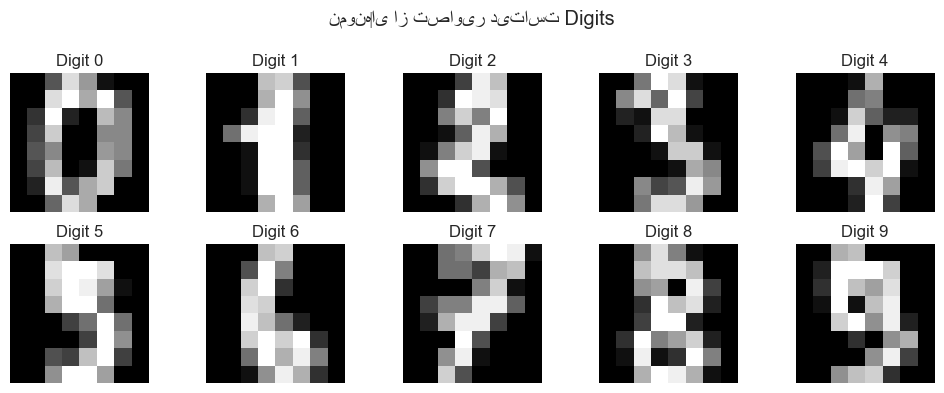

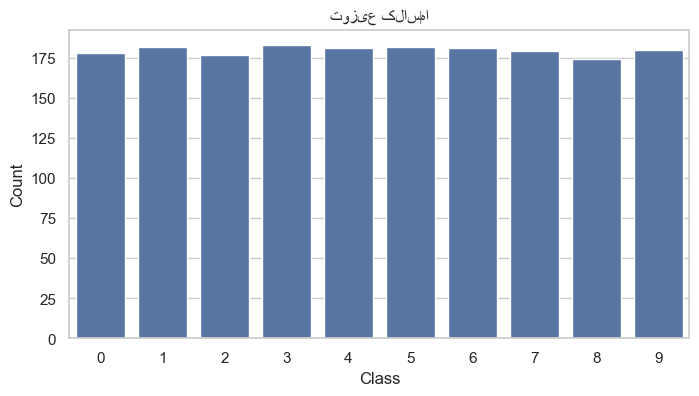

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, ax in enumerate(axes.ravel()):
    idx = np.where(y == digit)[0][0]
    ax.imshow(digits.images[idx], cmap="gray")
    ax.set_title(f"Digit {digit}")
    ax.axis("off")
plt.suptitle("نمونه‌ای از تصاویر دیتاست Digits")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(x=class_distribution.index, y=class_distribution.values, color="#4C72B0")
plt.title("توزیع کلاس‌ها")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### نتیجه‌گیری بخش دیتاست

توزیع کلاس‌ها تقریبا متوازن است؛ بنابراین Accuracy می‌تواند یک معیار اولیه قابل قبول باشد. با این حال حتی در دیتاست متوازن نیز Accuracy همه جنبه‌های عملکرد مدل را نشان نمی‌دهد. برای تحلیل کامل‌تر باید معیارهایی مانند Precision، Recall، F1، ROC-AUC، PR-AUC و نمودارهای خطا و یادگیری نیز بررسی شوند.

## ۳. تقسیم داده و تعریف مدل‌ها

داده به دو بخش آموزش و آزمون تقسیم می‌شود. از `stratify=y` استفاده می‌شود تا نسبت کلاس‌ها در هر دو بخش حفظ شود. برای مدل‌هایی مانند Logistic Regression و MLP، مقیاس‌بندی ویژگی‌ها ضروری است؛ بنابراین از `StandardScaler` داخل `Pipeline` استفاده می‌شود.

مدل اصلی این نوت‌بوک `MLPClassifier` است. این مدل یک شبکه عصبی feed-forward ساده را با ابزارهای خود `scikit-learn` پیاده‌سازی می‌کند.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

models = {
    "Dummy baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
        ]
    ),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "MLP Neural Network": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "model",
                MLPClassifier(
                    hidden_layer_sizes=(64, 32),
                    activation="relu",
                    alpha=1e-4,
                    learning_rate_init=0.001,
                    max_iter=400,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

for name, model in models.items():
    model.fit(X_train, y_train)

print("Models trained.")

Models trained.


## ۴. معیارهای پایه طبقه‌بندی

معیارهای پایه شامل Accuracy، Precision، Recall و F1-score هستند.

- **Accuracy** نسبت پیش‌بینی‌های درست به کل نمونه‌هاست.
- **Precision** نشان می‌دهد از میان نمونه‌هایی که مدل یک کلاس را مثبت تشخیص داده، چه تعداد واقعا متعلق به آن کلاس بوده‌اند.
- **Recall** نشان می‌دهد مدل چه بخشی از نمونه‌های واقعی یک کلاس را پیدا کرده است.
- **F1-score** میانگین هارمونیک Precision و Recall است و زمانی مفید است که تعادل بین این دو معیار اهمیت دارد.

در مسئله چندکلاسه، از میانگین `macro` استفاده می‌شود تا عملکرد مدل روی همه کلاس‌ها با وزن برابر بررسی شود.

,model,accuracy,precision_macro,recall_macro,f1_macro
1,Logistic Regression,0.977778,0.977767,0.977661,0.977641
3,Random Forest,0.968889,0.969450,0.968365,0.968346
4,MLP Neural Network,0.966667,0.967054,0.966598,0.966588
2,Decision Tree,0.835556,0.840397,0.834825,0.835585
0,Dummy baseline,0.102222,0.010222,0.100000,0.018548


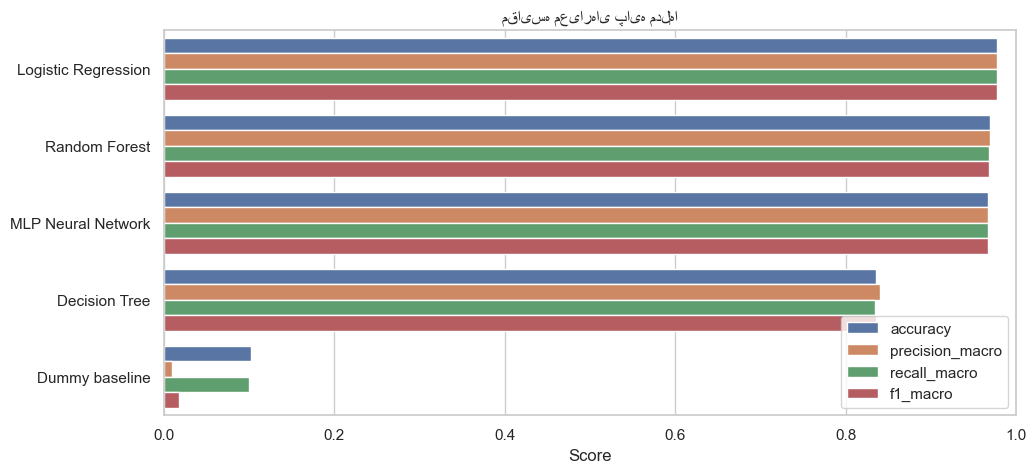

In [6]:
summary_rows = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    summary_rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        }
    )

metrics_df = pd.DataFrame(summary_rows).sort_values("f1_macro", ascending=False)
display(metrics_df)

plt.figure(figsize=(11, 5))
plot_df = metrics_df.melt(id_vars="model", var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="score", y="model", hue="metric")
plt.xlim(0, 1)
plt.title("مقایسه معیارهای پایه مدل‌ها")
plt.xlabel("Score")
plt.ylabel("")
plt.legend(loc="lower right")
plt.show()

              precision    recall  f1-score   support

           0      1.000     0.978     0.989        45
           1      0.935     0.935     0.935        46
           2      0.957     1.000     0.978        44
           3      0.978     0.978     0.978        46
           4      0.956     0.956     0.956        45
           5      0.978     0.978     0.978        46
           6      1.000     0.956     0.977        45
           7      0.938     1.000     0.968        45
           8      0.952     0.930     0.941        43
           9      0.977     0.956     0.966        45

    accuracy                          0.967       450
   macro avg      0.967     0.967     0.967       450
weighted avg      0.967     0.967     0.967       450



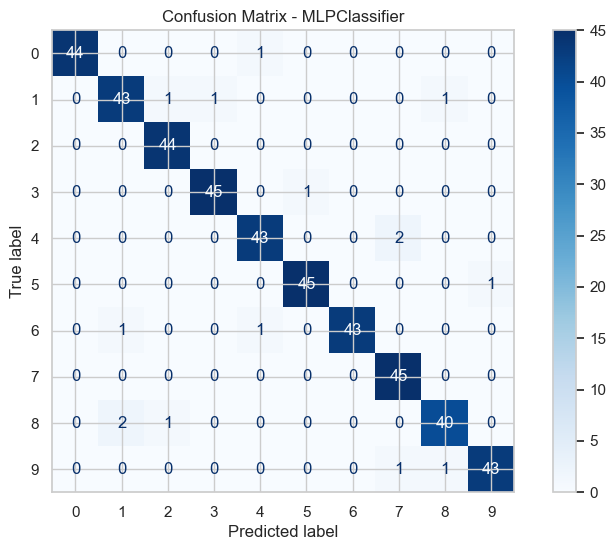

In [7]:
mlp_model = models["MLP Neural Network"]
y_pred_mlp = mlp_model.predict(X_test)

print(classification_report(y_test, y_pred_mlp, digits=3))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_mlp,
    cmap="Blues",
    display_labels=class_names,
)
plt.title("Confusion Matrix - MLPClassifier")
plt.show()

### نتیجه‌گیری معیارهای پایه

مدل Dummy نشان می‌دهد که یک baseline بسیار ساده چه سطحی از عملکرد دارد. هر مدلی که نتواند به شکل معنادار از baseline بهتر باشد، ارزش عملی ندارد. مدل‌های Logistic Regression، Random Forest و MLP معمولا روی این دیتاست عملکرد بالایی دارند، زیرا الگوهای تصویری Digits قابل یادگیری و نسبتا تمیز هستند.

ماتریس درهم‌ریختگی نشان می‌دهد خطاها بین کدام ارقام رخ می‌دهند. این نمودار از Accuracy اطلاعات بیشتری می‌دهد، چون مشخص می‌کند مدل دقیقا کدام کلاس‌ها را با هم اشتباه می‌گیرد.

## ۵. Accuracy Curve

Accuracy Curve می‌تواند تغییرات دقت را در شرایط مختلف نشان دهد. در اینجا دقت train و test برای چند مدل مقایسه می‌شود. فاصله زیاد بین دقت train و test معمولا نشانه overfitting است. دقت پایین در هر دو بخش معمولا نشانه underfitting یا bias بالا است.

,model,train_accuracy,test_accuracy
0,Dummy baseline,0.101707,0.102222
1,Logistic Regression,1.000000,0.977778
2,Decision Tree,0.988864,0.835556
3,Random Forest,1.000000,0.968889
4,MLP Neural Network,1.000000,0.966667


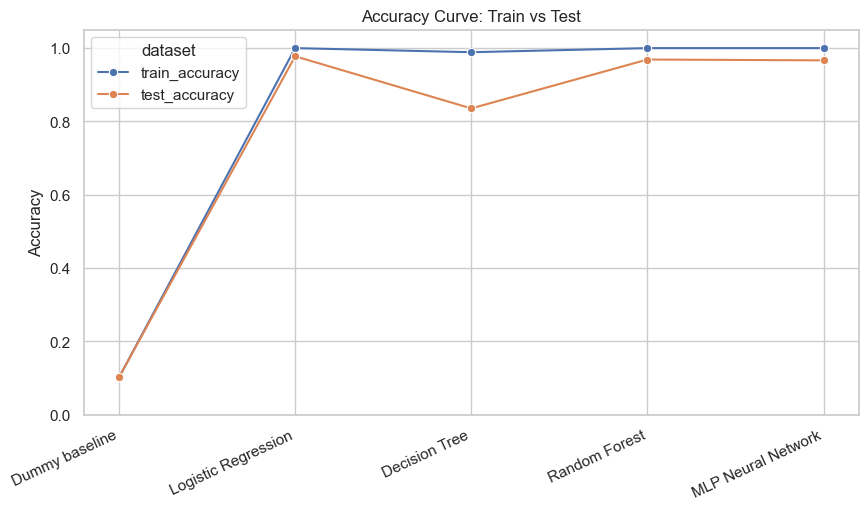

In [8]:
accuracy_rows = []
for name, model in models.items():
    accuracy_rows.append(
        {
            "model": name,
            "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
            "test_accuracy": accuracy_score(y_test, model.predict(X_test)),
        }
    )

accuracy_df = pd.DataFrame(accuracy_rows)
display(accuracy_df)

plt.figure(figsize=(10, 5))
acc_plot_df = accuracy_df.melt(id_vars="model", var_name="dataset", value_name="accuracy")
sns.lineplot(data=acc_plot_df, x="model", y="accuracy", hue="dataset", marker="o")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.title("Accuracy Curve: Train vs Test")
plt.xlabel("")
plt.ylabel("Accuracy")
plt.show()

### نتیجه‌گیری Accuracy Curve

اگر مدل روی داده آموزش دقت بسیار بالا و روی داده آزمون دقت پایین‌تری داشته باشد، مدل بخشی از الگوهای خاص داده آموزش را حفظ کرده و تعمیم ضعیف‌تری دارد. اگر هر دو دقت پایین باشند، مدل ظرفیت کافی ندارد یا ویژگی‌ها برای مسئله مناسب نیستند. در این دیتاست، مدل‌های قوی‌تر معمولا اختلاف کمی بین train و test دارند و این نشانه تعمیم مناسب است.

## ۶. Bias-Variance Trade-off

Bias و Variance دو منبع اصلی خطای مدل هستند.

- **Bias بالا** یعنی مدل بیش از حد ساده است و ساختار واقعی داده را خوب یاد نمی‌گیرد.
- **Variance بالا** یعنی مدل بیش از حد پیچیده است و به جزئیات خاص داده آموزش حساس می‌شود.

برای نمایش این مفهوم، از `DecisionTreeClassifier` با عمق‌های مختلف استفاده می‌شود. درخت کم‌عمق معمولا bias بالا دارد. درخت بسیار عمیق معمولا variance بالا دارد.

,max_depth,train_accuracy,test_accuracy
0,1,0.200445,0.191111
1,2,0.322940,0.306667
2,3,0.492947,0.475556
3,4,0.599109,0.575556
4,5,0.709725,0.664444


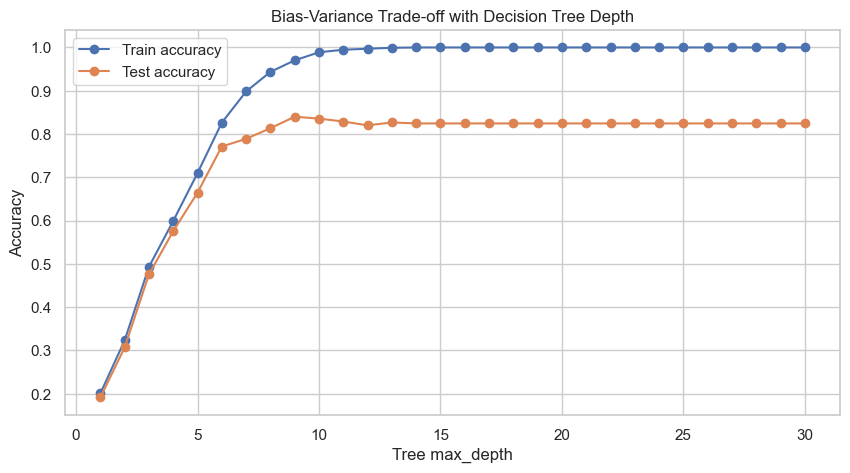

In [9]:
depths = range(1, 31)
bias_variance_rows = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    bias_variance_rows.append(
        {
            "max_depth": depth,
            "train_accuracy": accuracy_score(y_train, tree.predict(X_train)),
            "test_accuracy": accuracy_score(y_test, tree.predict(X_test)),
        }
    )

bv_df = pd.DataFrame(bias_variance_rows)
display(bv_df.head())

plt.figure(figsize=(10, 5))
plt.plot(bv_df["max_depth"], bv_df["train_accuracy"], marker="o", label="Train accuracy")
plt.plot(bv_df["max_depth"], bv_df["test_accuracy"], marker="o", label="Test accuracy")
plt.xlabel("Tree max_depth")
plt.ylabel("Accuracy")
plt.title("Bias-Variance Trade-off with Decision Tree Depth")
plt.legend()
plt.show()

### نتیجه‌گیری Bias-Variance

در عمق‌های کم، هم دقت آموزش و هم دقت آزمون پایین‌تر است؛ این حالت نشان‌دهنده bias بالاست. با افزایش عمق، مدل بهتر یاد می‌گیرد و دقت آزمون افزایش می‌یابد. اما پس از یک نقطه، دقت آموزش همچنان بالا می‌رود یا ثابت می‌ماند، در حالی که دقت آزمون بهبود قابل توجهی ندارد یا کاهش می‌یابد. این حالت نشانه variance بالا و overfitting است.

نقطه مناسب معمولا جایی است که دقت آزمون بالا و فاصله بین train و test قابل قبول باشد.

## ۷. Learning Curve

Learning Curve اثر تعداد نمونه‌های آموزشی را بر عملکرد مدل نشان می‌دهد. این نمودار برای پاسخ به این پرسش استفاده می‌شود که آیا افزایش داده می‌تواند عملکرد مدل را بهتر کند یا مشکل اصلی از ظرفیت مدل، ویژگی‌ها یا تنظیمات یادگیری است.

در این بخش از `learning_curve` با اعتبارسنجی متقاطع استفاده می‌شود.

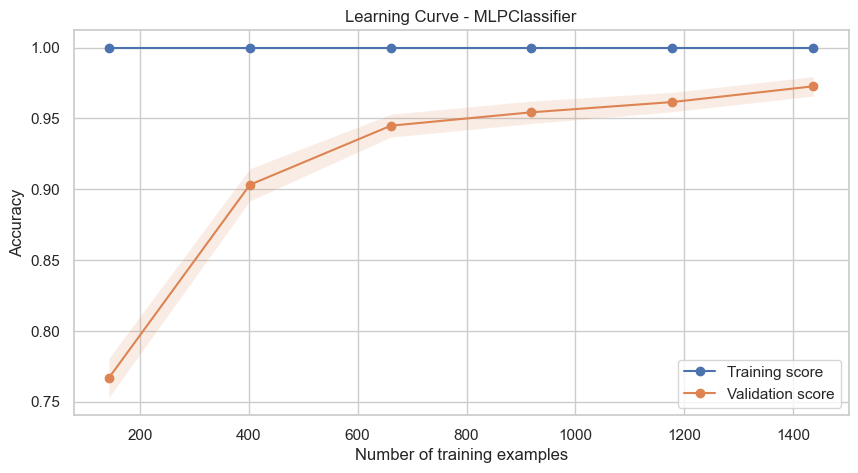

In [10]:
mlp_for_curve = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                alpha=1e-4,
                max_iter=350,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_sizes, train_scores, validation_scores = learning_curve(
    mlp_for_curve,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 6),
    n_jobs=1,
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = validation_scores.mean(axis=1)
val_std = validation_scores.std(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training score")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.plot(train_sizes, val_mean, marker="o", label="Validation score")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
plt.xlabel("Number of training examples")
plt.ylabel("Accuracy")
plt.title("Learning Curve - MLPClassifier")
plt.legend()
plt.show()

### نتیجه‌گیری Learning Curve

اگر با افزایش تعداد نمونه‌ها امتیاز اعتبارسنجی همچنان رشد کند، جمع‌آوری داده بیشتر می‌تواند مفید باشد. اگر امتیاز آموزش و اعتبارسنجی هر دو پایین باشند، مدل دچار underfitting است. اگر امتیاز آموزش بالا و امتیاز اعتبارسنجی پایین باشد، مدل overfit شده است.

در این دیتاست، با افزایش داده، امتیاز اعتبارسنجی معمولا پایدارتر و بهتر می‌شود. نزدیک شدن دو منحنی نشان می‌دهد مدل در حال رسیدن به تعمیم مناسب است.

## ۸. Validation Curve

Validation Curve اثر تغییر یک hyperparameter را بر عملکرد مدل نشان می‌دهد. برخلاف Learning Curve که تعداد داده را تغییر می‌دهد، در Validation Curve ظرفیت یا تنظیمات مدل تغییر می‌کند.

در اینجا اثر `max_depth` در درخت تصمیم بررسی می‌شود. این پارامتر مستقیما پیچیدگی مدل را کنترل می‌کند.

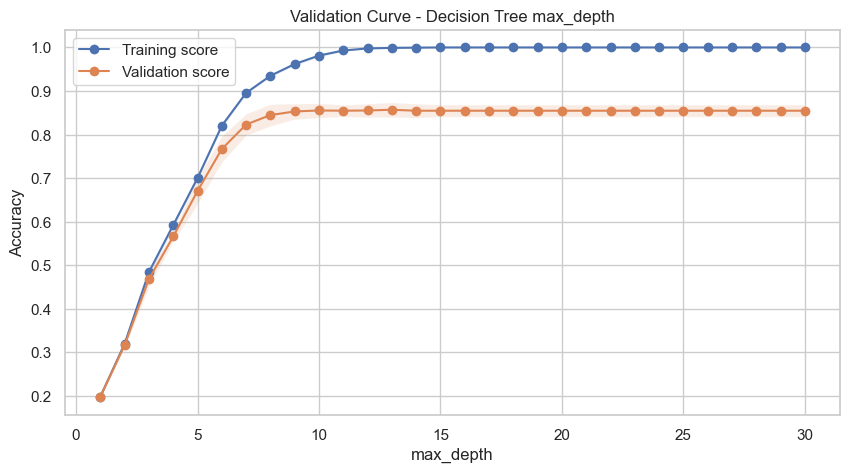

In [11]:
param_range = np.arange(1, 31)
train_scores, validation_scores = validation_curve(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    X,
    y,
    param_name="max_depth",
    param_range=param_range,
    cv=cv,
    scoring="accuracy",
    n_jobs=1,
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = validation_scores.mean(axis=1)
val_std = validation_scores.std(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(param_range, train_mean, marker="o", label="Training score")
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.plot(param_range, val_mean, marker="o", label="Validation score")
plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, alpha=0.15)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Validation Curve - Decision Tree max_depth")
plt.legend()
plt.show()

### نتیجه‌گیری Validation Curve

در عمق‌های کم، مدل ساده است و خطای bias بالاست. با افزایش عمق، عملکرد اعتبارسنجی بهتر می‌شود. اما پس از یک محدوده، افزایش پیچیدگی باعث بهبود واقعی نمی‌شود و فقط دقت آموزش را بالا نگه می‌دارد. این رفتار نشان می‌دهد که انتخاب hyperparameter باید بر اساس عملکرد اعتبارسنجی انجام شود، نه صرفا عملکرد آموزش.

## ۹. ROC Curve و AUC

ROC Curve رابطه بین نرخ مثبت واقعی و نرخ مثبت کاذب را در thresholdهای مختلف نشان می‌دهد.

- **True Positive Rate / Recall**: چه بخشی از نمونه‌های مثبت واقعی پیدا شده‌اند.
- **False Positive Rate**: چه بخشی از نمونه‌های منفی به اشتباه مثبت پیش‌بینی شده‌اند.
- **AUC** سطح زیر منحنی ROC است و هرچه به ۱ نزدیک‌تر باشد، توان جداسازی مدل بهتر است.

برای تحلیل شفاف‌تر، مسئله به حالت دودویی تبدیل می‌شود: تشخیص رقم ۸ در برابر سایر ارقام.

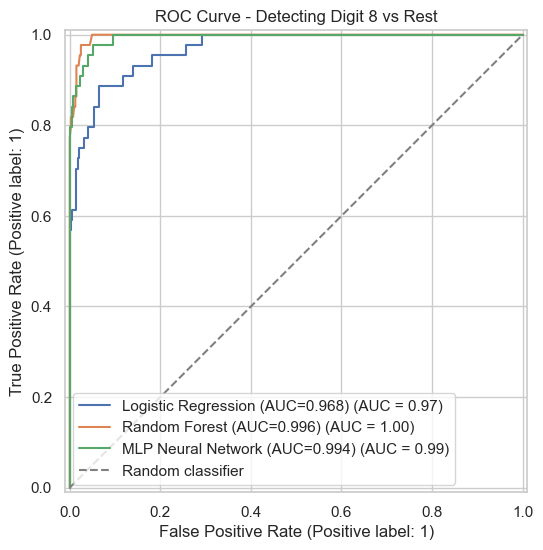

,model,roc_auc
1,Random Forest,0.996333
2,MLP Neural Network,0.993842
0,Logistic Regression,0.968148


In [12]:
y_binary = (y == 8).astype(int)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X,
    y_binary,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_binary,
)

binary_models = {
    "Logistic Regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
        ]
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "MLP Neural Network": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "model",
                MLPClassifier(
                    hidden_layer_sizes=(64, 32),
                    max_iter=400,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

plt.figure(figsize=(8, 6))
roc_rows = []
for name, model in binary_models.items():
    model.fit(X_train_b, y_train_b)
    scores = model.predict_proba(X_test_b)[:, 1]
    auc = roc_auc_score(y_test_b, scores)
    RocCurveDisplay.from_predictions(y_test_b, scores, name=f"{name} (AUC={auc:.3f})", ax=plt.gca())
    roc_rows.append({"model": name, "roc_auc": auc})

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
plt.title("ROC Curve - Detecting Digit 8 vs Rest")
plt.legend()
plt.show()

display(pd.DataFrame(roc_rows).sort_values("roc_auc", ascending=False))

### نتیجه‌گیری ROC Curve

ROC-AUC توان مدل در رتبه‌بندی نمونه‌های مثبت بالاتر از نمونه‌های منفی را نشان می‌دهد. اگر AUC بالا باشد، مدل در جداسازی کلاس مثبت از منفی توانمند است. ROC Curve زمانی مفید است که بخواهیم اثر تغییر threshold را مستقل از یک threshold ثابت بررسی کنیم.

با این حال، در داده‌های بسیار نامتوازن، ROC ممکن است بیش از حد خوش‌بینانه به نظر برسد. در چنین شرایطی Precision-Recall Curve معمولا اطلاعات عملی‌تری ارائه می‌دهد.

## ۱۰. Precision-Recall Curve و Trade-off

Precision-Recall Curve رابطه بین Precision و Recall را در thresholdهای مختلف نشان می‌دهد.

افزایش Recall معمولا با کاهش Precision همراه است، زیرا مدل برای پیدا کردن مثبت‌های بیشتر، نمونه‌های بیشتری را مثبت اعلام می‌کند و احتمال مثبت کاذب افزایش می‌یابد. برعکس، افزایش Precision معمولا باعث کاهش Recall می‌شود، چون مدل سخت‌گیرتر می‌شود.

این منحنی به‌ویژه در مسئله‌هایی اهمیت دارد که کلاس مثبت کمیاب یا هزینه خطاها نامتقارن است.

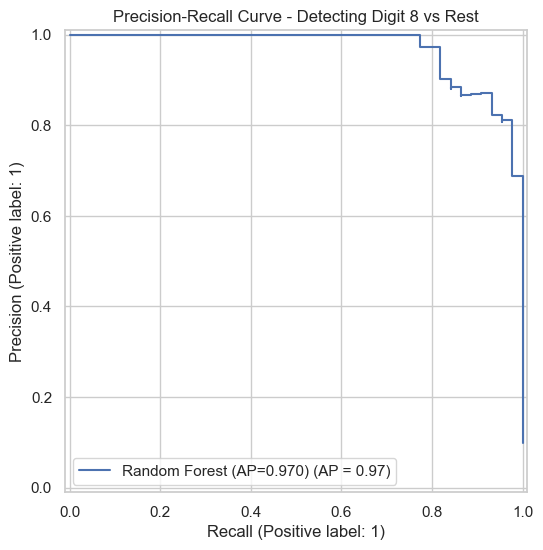

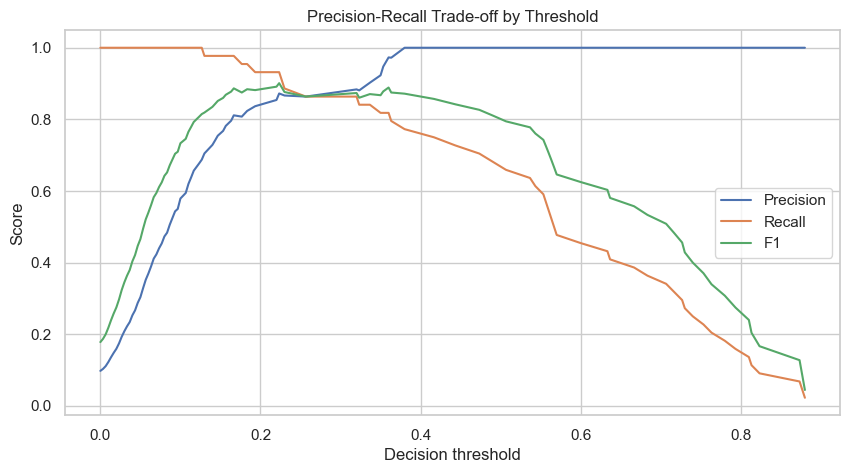

,threshold,precision,recall,f1
0,0.000,0.098,1.000,0.178
9,0.030,0.209,1.000,0.345
18,0.060,0.370,1.000,0.540
27,0.093,0.543,1.000,0.704
36,0.130,0.705,0.977,0.819
45,0.183,0.824,0.955,0.884
54,0.337,0.902,0.841,0.871
63,0.490,1.000,0.682,0.811
72,0.570,1.000,0.477,0.646
81,0.730,1.000,0.273,0.429


In [13]:
best_binary_name = max(roc_rows, key=lambda row: row["roc_auc"])["model"]
best_binary_model = binary_models[best_binary_name]
scores = best_binary_model.predict_proba(X_test_b)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test_b, scores)
ap = average_precision_score(y_test_b, scores)

PrecisionRecallDisplay.from_predictions(
    y_test_b,
    scores,
    name=f"{best_binary_name} (AP={ap:.3f})",
)
plt.title("Precision-Recall Curve - Detecting Digit 8 vs Rest")
plt.show()

threshold_df = pd.DataFrame(
    {
        "threshold": thresholds,
        "precision": precision[:-1],
        "recall": recall[:-1],
    }
)
threshold_df["f1"] = (
    2 * threshold_df["precision"] * threshold_df["recall"]
    / (threshold_df["precision"] + threshold_df["recall"]).replace(0, np.nan)
)

plt.figure(figsize=(10, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off by Threshold")
plt.legend()
plt.show()

display(threshold_df.iloc[:: max(1, len(threshold_df)//10)].round(3))

### نتیجه‌گیری Precision-Recall Trade-off

Threshold پیش‌فرض معمولا ۰.۵ است، اما همیشه بهترین انتخاب نیست. اگر هدف کاهش از دست دادن نمونه‌های مثبت باشد، threshold پایین‌تر انتخاب می‌شود و Recall افزایش می‌یابد. اگر هدف اطمینان بیشتر از مثبت‌های اعلام‌شده باشد، threshold بالاتر انتخاب می‌شود و Precision افزایش می‌یابد.

انتخاب threshold یک تصمیم فنی و وابسته به هزینه خطاهاست. در کاربردهای حساس، معیار بهینه باید بر اساس پیامد False Positive و False Negative تعیین شود.

## ۱۱. Loss Curve با شبکه عصبی ساده

Loss Curve مقدار تابع هزینه را در طول epochهای آموزش نشان می‌دهد. در `MLPClassifier` مقدار loss در ویژگی `loss_curve_` ذخیره می‌شود.

کاهش پیوسته loss نشان می‌دهد فرایند بهینه‌سازی در حال یادگیری است. اگر loss نوسان شدید داشته باشد، ممکن است نرخ یادگیری زیاد باشد. اگر loss خیلی زود ثابت شود و عملکرد ضعیف بماند، ممکن است مدل ظرفیت کافی نداشته باشد یا تنظیمات بهینه نباشد.

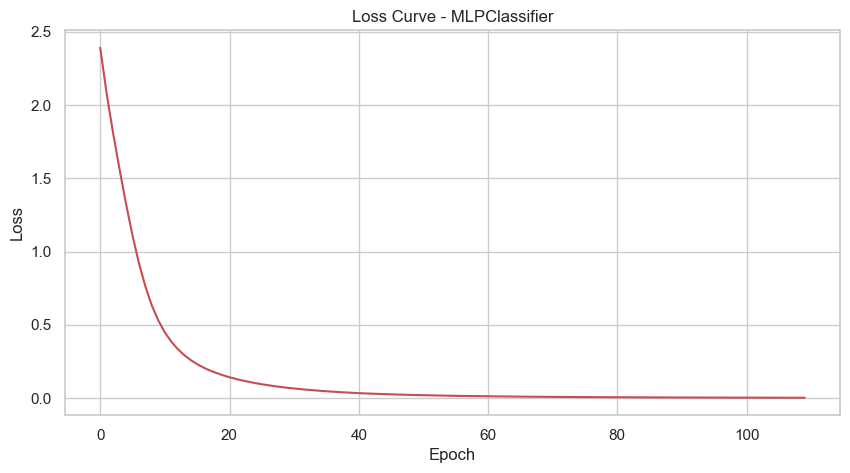

Final loss: 0.0033
Test accuracy: 0.9667


In [18]:
mlp_loss_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                learning_rate_init=0.001,
                max_iter=400,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

mlp_loss_model.fit(X_train, y_train)
loss_curve_values = mlp_loss_model.named_steps["model"].loss_curve_

plt.figure(figsize=(10, 5))
plt.plot(loss_curve_values, "r")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve - MLPClassifier")
plt.show()

print("Final loss:", round(loss_curve_values[-1], 4))
print("Test accuracy:", round(accuracy_score(y_test, mlp_loss_model.predict(X_test)), 4))

### نتیجه‌گیری Loss Curve

Loss Curve رفتار فرایند یادگیری را از دید optimization نشان می‌دهد، نه فقط عملکرد نهایی مدل را. اگر loss کاهش یابد اما عملکرد آزمون خوب نباشد، ممکن است مدل بیش از حد روی داده آموزش متمرکز شده باشد یا معیار loss با هدف عملی مسئله هم‌راستا نباشد. بنابراین Loss Curve باید همراه با معیارهای آزمون و اعتبارسنجی تحلیل شود.

## ۱۲. Accuracy و Loss در طول epoch

برای مشاهده همزمان تغییرات Accuracy و Loss، می‌توان شبکه عصبی را به صورت تدریجی با `partial_fit` آموزش داد. در هر epoch، loss و accuracy روی train و test ثبت می‌شود.

این روش تصویری نزدیک‌تر به روند آموزش شبکه عصبی فراهم می‌کند.

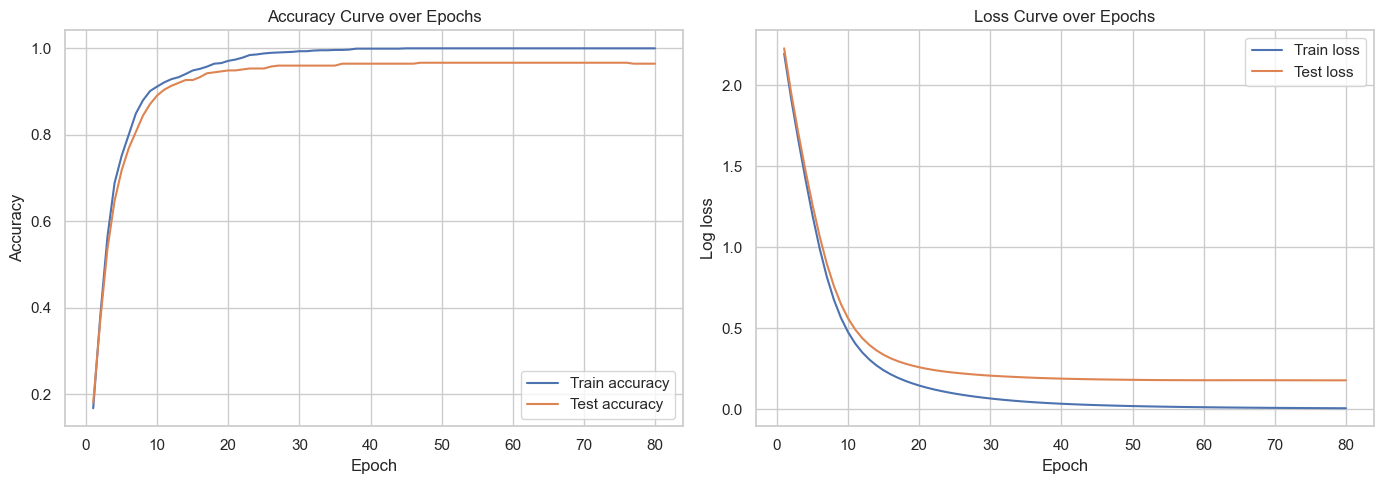

,epoch,train_accuracy,test_accuracy,train_loss,test_loss
75,76,1.0,0.9667,0.0071,0.1787
76,77,1.0,0.9644,0.0069,0.1787
77,78,1.0,0.9644,0.0067,0.1786
78,79,1.0,0.9644,0.0065,0.1786
79,80,1.0,0.9644,0.0063,0.1785


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

epoch_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=0.001,
    max_iter=1,
    warm_start=True,
    random_state=RANDOM_STATE,
)

classes = np.unique(y_train)
history = []
for epoch in range(1, 81):
    epoch_model.partial_fit(X_train_scaled, y_train, classes=classes)
    train_pred = epoch_model.predict(X_train_scaled)
    test_pred = epoch_model.predict(X_test_scaled)
    train_proba = epoch_model.predict_proba(X_train_scaled)
    test_proba = epoch_model.predict_proba(X_test_scaled)
    history.append(
        {
            "epoch": epoch,
            "train_accuracy": accuracy_score(y_train, train_pred),
            "test_accuracy": accuracy_score(y_test, test_pred),
            "train_loss": log_loss(y_train, train_proba, labels=classes),
            "test_loss": log_loss(y_test, test_proba, labels=classes),
        }
    )

history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_df["epoch"], history_df["train_accuracy"], label="Train accuracy")
axes[0].plot(history_df["epoch"], history_df["test_accuracy"], label="Test accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy Curve over Epochs")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
axes[1].plot(history_df["epoch"], history_df["test_loss"], label="Test loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Log loss")
axes[1].set_title("Loss Curve over Epochs")
axes[1].legend()

plt.tight_layout()
plt.show()

display(history_df.tail().round(4))

### نتیجه‌گیری Accuracy و Loss در طول epoch

اگر train accuracy افزایش یابد اما test accuracy پس از مدتی ثابت بماند یا افت کند، نشانه overfitting است. اگر train loss کاهش یابد اما test loss افزایش پیدا کند، مدل در حال بهتر شدن روی داده آموزش و بدتر شدن از نظر تعمیم است. بهترین نقطه آموزش معمولا قبل از شروع افزایش test loss یا قبل از ایجاد فاصله زیاد بین train و test قرار دارد.

## ۱۳. Cross Validation

یک تقسیم train/test تنها یک برآورد از عملکرد مدل می‌دهد و ممکن است به نحوه تقسیم داده حساس باشد. Cross Validation داده را چند بار به بخش‌های آموزش و اعتبارسنجی تقسیم می‌کند و میانگین و انحراف معیار عملکرد را گزارش می‌دهد.

در طبقه‌بندی، `StratifiedKFold` باعث می‌شود نسبت کلاس‌ها در foldها حفظ شود.

In [16]:
cv_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                max_iter=350,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
}

cv_results = cross_validate(
    cv_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=True,
)

cv_summary = []
for metric in scoring:
    cv_summary.append(
        {
            "metric": metric,
            "train_mean": cv_results[f"train_{metric}"].mean(),
            "train_std": cv_results[f"train_{metric}"].std(),
            "validation_mean": cv_results[f"test_{metric}"].mean(),
            "validation_std": cv_results[f"test_{metric}"].std(),
        }
    )

display(pd.DataFrame(cv_summary).round(4))

,metric,train_mean,train_std,validation_mean,validation_std
0,accuracy,1.0,0.0,0.9738,0.0080
1,precision_macro,1.0,0.0,0.9747,0.0077
2,recall_macro,1.0,0.0,0.9738,0.0080
3,f1_macro,1.0,0.0,0.9738,0.0080


### نتیجه‌گیری Cross Validation

میانگین عملکرد نشان‌دهنده برآورد کلی مدل است و انحراف معیار میزان پایداری آن را نشان می‌دهد. اگر انحراف معیار زیاد باشد، مدل به تقسیم داده حساس است. اگر اختلاف train و validation زیاد باشد، احتمال overfitting وجود دارد.

Cross Validation برای مقایسه مدل‌ها و انتخاب hyperparameter قابل اعتمادتر از یک تقسیم ساده train/test است.

## ۱۴. ROC-AUC چندکلاسه با One-vs-Rest

در مسئله چندکلاسه نیز می‌توان ROC-AUC را با روش One-vs-Rest محاسبه کرد. در این روش برای هر کلاس، همان کلاس مثبت و همه کلاس‌های دیگر منفی در نظر گرفته می‌شوند. سپس میانگین macro یا weighted محاسبه می‌شود.

Macro ROC-AUC: 0.9964
Weighted ROC-AUC: 0.9964


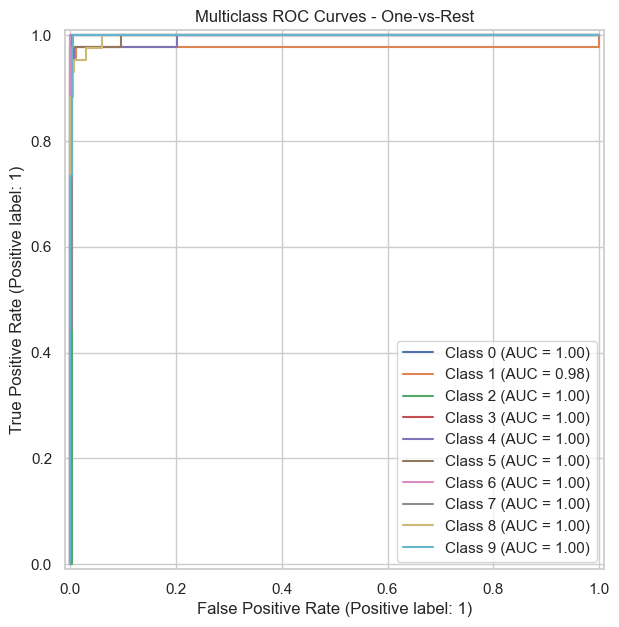

In [17]:
multi_mlp = models["MLP Neural Network"]
y_score_multi = multi_mlp.predict_proba(X_test)
y_test_binarized = label_binarize(y_test, classes=class_names)

macro_roc_auc = roc_auc_score(
    y_test_binarized,
    y_score_multi,
    average="macro",
    multi_class="ovr",
)
weighted_roc_auc = roc_auc_score(
    y_test_binarized,
    y_score_multi,
    average="weighted",
    multi_class="ovr",
)

print("Macro ROC-AUC:", round(macro_roc_auc, 4))
print("Weighted ROC-AUC:", round(weighted_roc_auc, 4))

plt.figure(figsize=(9, 7))
for class_id in class_names:
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, class_id],
        y_score_multi[:, class_id],
        name=f"Class {class_id}",
        ax=plt.gca(),
    )
plt.title("Multiclass ROC Curves - One-vs-Rest")
plt.show()

### نتیجه‌گیری ROC-AUC چندکلاسه

روش One-vs-Rest امکان تحلیل جداگانه هر کلاس را فراهم می‌کند. اگر یک کلاس ROC ضعیف‌تری داشته باشد، مدل در جداسازی آن کلاس از بقیه مشکل بیشتری دارد. میانگین macro برای بررسی عملکرد برابر روی همه کلاس‌ها مناسب است، در حالی که میانگین weighted به فراوانی کلاس‌ها وزن می‌دهد.

## ۱۵. جمع‌بندی نهایی

در ارزیابی مدل نباید به یک معیار اکتفا کرد. هر معیار بخشی از رفتار مدل را نشان می‌دهد:

| روش | کاربرد اصلی | نکته تفسیری |
|---|---|---|
| Accuracy | ارزیابی اولیه در داده متوازن | در داده نامتوازن می‌تواند گمراه‌کننده باشد |
| Confusion Matrix | مشاهده نوع خطاها | نشان می‌دهد کدام کلاس‌ها با هم اشتباه می‌شوند |
| Precision | کنترل مثبت‌های کاذب | وقتی اعلام مثبت باید قابل اعتماد باشد مهم است |
| Recall | کنترل منفی‌های کاذب | وقتی از دست دادن مثبت‌ها پرهزینه است مهم است |
| F1-score | تعادل Precision و Recall | برای مقایسه کلی در مسائل نامتوازن مفید است |
| ROC Curve | تحلیل جداسازی در thresholdهای مختلف | برای بررسی توان رتبه‌بندی مدل مناسب است |
| Precision-Recall Curve | تحلیل مثبت‌های کمیاب یا هزینه نامتقارن | در داده نامتوازن معمولا از ROC عملی‌تر است |
| Learning Curve | اثر تعداد داده بر عملکرد | نشان می‌دهد داده بیشتر احتمالا کمک می‌کند یا نه |
| Validation Curve | اثر hyperparameter بر bias و variance | برای انتخاب پیچیدگی مناسب مدل کاربرد دارد |
| Loss Curve | بررسی روند بهینه‌سازی | باید همراه با معیارهای validation/test تفسیر شود |
| Cross Validation | برآورد پایدارتر عملکرد | میانگین و انحراف معیار را فراهم می‌کند |

نتیجه کلی این است که ارزیابی مدل یک فرایند چندبعدی است. مدل خوب فقط مدلی نیست که Accuracy بالایی دارد؛ بلکه مدلی است که روی داده دیده‌نشده پایدار، قابل تعمیم و متناسب با هزینه خطاهای مسئله عمل کند.